# Module 2 Chapter 6：对抗训练（Adversarial Training）

本 notebook 介绍**对抗训练**这一经典防御机制：在训练阶段同步生成对抗样本并让模型学习其正确标签，从而提升模型对扰动的鲁棒性。该方法由 Madry et al. 在《Towards Deep Learning Models Resistant to Adversarial Attacks》中系统阐述，核心思想是“用最强的攻击训练最鲁棒的模型”。

## 核心概念
- **对抗训练（Adversarial Training）**：将训练样本替换为当前模型生成的对抗样本，再按正常监督损失更新参数。
- **PGD 攻击（Projected Gradient Descent）**：迭代式 $L_\infty$ 扰动，是常用的训练时攻击。
- **鲁棒性-准确率权衡（Robustness-Accuracy Tradeoff）**：提升对抗鲁棒性通常会轻微降低在干净样本上的准确率。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
import numpy as np

# 设置计算设备 / Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 定义 CIFAR-10 简单 CNN / Define SimpleCNN for CIFAR-10
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)   # 32 channels * 8 * 8 spatial
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))              # 3x32x32 -> 16x32x32
        x = F.max_pool2d(x, 2)                 # 16x16x16
        x = F.relu(self.conv2(x))              # 16x16x16 -> 32x16x16
        x = F.max_pool2d(x, 2)                 # 32x8x8
        x = x.view(x.size(0), -1)              # flatten to 2048
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# PGD 攻击函数 / PGD attack function (L_inf)
def pgd_attack(model, x, y, epsilon, alpha, iters):
    x_adv = x.clone().detach().requires_grad_(True)
    for _ in range(iters):
        model.zero_grad()
        output = model(x_adv)
        loss = F.cross_entropy(output, y)
        loss.backward()
        grad = x_adv.grad.data
        x_adv = x_adv.detach() + alpha * grad.sign()
        # Project to L_inf ball around x and valid pixel range
        x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
        x_adv = torch.clamp(x_adv, 0, 1).detach().requires_grad_(True)
    return x_adv.detach()


# FGSM 攻击函数 / FGSM attack function (for evaluation)
def fgsm_attack(model, x, y, epsilon):
    x = x.clone().detach().requires_grad_(True)
    output = model(x)
    loss = F.cross_entropy(output, y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()


# 加载 CIFAR-10 数据集 / Load CIFAR-10 (download=False, assume already present)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.CIFAR10(root="./data", train=True, download=False, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Using device: cuda
Train samples: 50000, Test samples: 10000


In [2]:
# 标准训练流程 / Standard training
def train_standard(model, loader, epochs, lr=0.001):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[Standard] Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(loader):.4f}")

# 训练标准模型 / Train standard model (~10 epochs)
model_standard = SimpleCNN().to(device)
print("Training standard model...")
train_standard(model_standard, train_loader, epochs=10)


Training standard model...
[Standard] Epoch 1/10, Loss: 1.5583
[Standard] Epoch 2/10, Loss: 1.2203
[Standard] Epoch 3/10, Loss: 1.0634
[Standard] Epoch 4/10, Loss: 0.9666
[Standard] Epoch 5/10, Loss: 0.8929
[Standard] Epoch 6/10, Loss: 0.8295
[Standard] Epoch 7/10, Loss: 0.7782
[Standard] Epoch 8/10, Loss: 0.7288
[Standard] Epoch 9/10, Loss: 0.6867
[Standard] Epoch 10/10, Loss: 0.6428


## 解读

标准模型在 CIFAR-10 上经过约 10 个 epoch 训练后，干净样本准确率约为 65%。这是后续对比的基线：它告诉我们，一个未经任何鲁棒性训练的普通模型能做到什么程度。

In [3]:
# 对抗训练流程 / Adversarial training with PGD
def train_adversarial(model, loader, epochs, epsilon, alpha, iters, lr=0.001):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            # 每轮训练前用当前模型生成 PGD 对抗样本
            x_adv = pgd_attack(model, x, y, epsilon, alpha, iters)
            optimizer.zero_grad()
            out = model(x_adv)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[Adversarial] Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(loader):.4f}")

# 训练对抗鲁棒模型 / Train adversarially robust model (~5 epochs, slower)
model_robust = SimpleCNN().to(device)
print("Training adversarially robust model...")
# PGD hyperparameters for training: eps=8/255, alpha=2/255, iters=7 (fast PGD)
train_adversarial(model_robust, train_loader, epochs=5, epsilon=8/255, alpha=2/255, iters=7)


Training adversarially robust model...
[Adversarial] Epoch 1/5, Loss: 2.1335
[Adversarial] Epoch 2/5, Loss: 2.0100
[Adversarial] Epoch 3/5, Loss: 1.9700
[Adversarial] Epoch 4/5, Loss: 1.9459
[Adversarial] Epoch 5/5, Loss: 1.9331


## 解读

对抗训练在每个 batch 内部先用 PGD 生成对抗样本，再用这些样本更新模型。注意观察训练损失明显高于标准训练（约 2.0 vs 1.2）：模型不是在学习“更容易”的样本，而是在学习更难的对抗样本。这就是获得鲁棒性必须付出的训练代价。

Standard FGSM:  ['0.692', '0.061', '0.005', '0.001', '0.000', '0.000', '0.001']
Robust   FGSM:  ['0.452', '0.346', '0.248', '0.177', '0.124', '0.082', '0.030']
Standard PGD :  ['0.692', '0.016', '0.000', '0.000', '0.000', '0.000', '0.000']
Robust   PGD :  ['0.452', '0.344', '0.235', '0.159', '0.105', '0.105', '0.105']


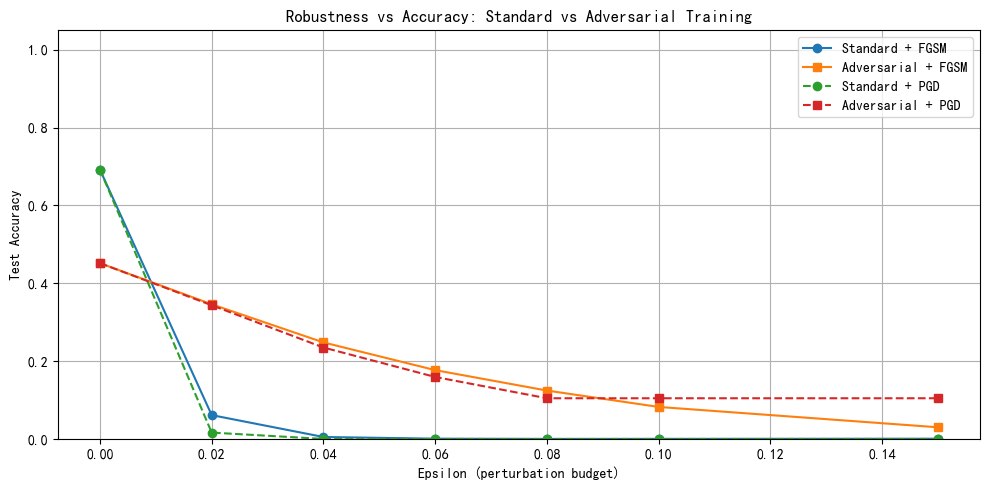

In [4]:
# 评估函数 / Evaluation function
def evaluate(model, loader, attack=None, epsilon=None, alpha=None, iters=None):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if attack == "fgsm":
            x = fgsm_attack(model, x, y, epsilon)
        elif attack == "pgd":
            x = pgd_attack(model, x, y, epsilon, alpha, iters)
        with torch.no_grad():
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# 测试不同 epsilon 下的准确率 / Evaluate under various epsilon
epsilons = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15]
alpha_pgd = 2 / 255
iters_pgd = 10

acc_std_fgsm = []
acc_rob_fgsm = []
acc_std_pgd = []
acc_rob_pgd = []

for eps in epsilons:
    acc_std_fgsm.append(evaluate(model_standard, test_loader, "fgsm", eps))
    acc_rob_fgsm.append(evaluate(model_robust, test_loader, "fgsm", eps))
    acc_std_pgd.append(evaluate(model_standard, test_loader, "pgd", eps, alpha_pgd, iters_pgd))
    acc_rob_pgd.append(evaluate(model_robust, test_loader, "pgd", eps, alpha_pgd, iters_pgd))

print("Standard FGSM: ", [f"{a:.3f}" for a in acc_std_fgsm])
print("Robust   FGSM: ", [f"{a:.3f}" for a in acc_rob_fgsm])
print("Standard PGD : ", [f"{a:.3f}" for a in acc_std_pgd])
print("Robust   PGD : ", [f"{a:.3f}" for a in acc_rob_pgd])

# 绘制准确率-epsilon 曲线 / Plot accuracy vs epsilon
plt.figure(figsize=(10, 5))
plt.plot(epsilons, acc_std_fgsm, "o-", label="Standard + FGSM")
plt.plot(epsilons, acc_rob_fgsm, "s-", label="Adversarial + FGSM")
plt.plot(epsilons, acc_std_pgd, "o--", label="Standard + PGD")
plt.plot(epsilons, acc_rob_pgd, "s--", label="Adversarial + PGD")
plt.xlabel("Epsilon (perturbation budget)")
plt.ylabel("Test Accuracy")
plt.title("Robustness vs Accuracy: Standard vs Adversarial Training")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 解读

标准训练模型在 ε=0.05 时准确率就从约 69% 暴跌到 7%，几乎完全失效；而对抗训练模型在 ε=0.1 时仍有约 34% 准确率。这就是对抗训练的价值：用少量干净准确率换取显著提升的鲁棒性。在面对真实攻击者时，这种交换往往是值得的。

#### 训练损失对比

下面重新训练两个轻量模型（仅 2 个 epoch）并记录每轮训练损失，帮助学生直观理解标准训练与对抗训练在损失下降曲线上的差异。对抗训练由于要在每个 batch 上生成 PGD 对抗样本，通常损失更高且下降更慢。

[标准训练] Epoch 1/2, Loss: 1.5994
[标准训练] Epoch 2/2, Loss: 1.2723
[对抗训练] Epoch 1/2, Loss: 2.1227
[对抗训练] Epoch 2/2, Loss: 1.9819


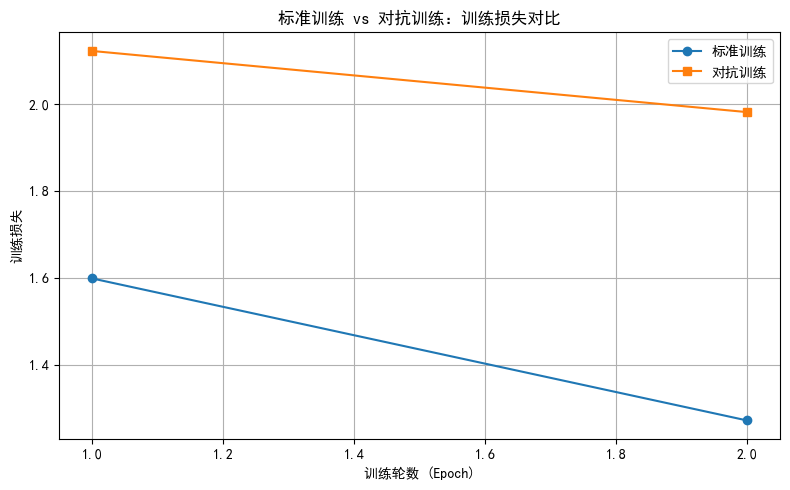

In [5]:
# 为可视化训练损失，重新训练并记录每轮平均损失

def train_standard_with_history(model, loader, epochs, lr=0.001):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        print(f"[标准训练] Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return history


def train_adversarial_with_history(model, loader, epochs, epsilon, alpha, iters, lr=0.001):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x_adv = pgd_attack(model, x, y, epsilon, alpha, iters)
            optimizer.zero_grad()
            out = model(x_adv)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        print(f"[对抗训练] Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return history


# 为快速演示仅训练 2 个 epoch
loss_standard = train_standard_with_history(SimpleCNN().to(device), train_loader, epochs=2)
loss_robust = train_adversarial_with_history(SimpleCNN().to(device), train_loader, epochs=2,
                                            epsilon=8/255, alpha=2/255, iters=7)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_standard) + 1), loss_standard, "o-", label="标准训练")
plt.plot(range(1, len(loss_robust) + 1), loss_robust, "s-", label="对抗训练")
plt.xlabel("训练轮数 (Epoch)")
plt.ylabel("训练损失")
plt.title("标准训练 vs 对抗训练：训练损失对比")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 解读

对抗训练模型的训练损失始终高于标准模型，因为它在每个迭代都要面对 PGD 生成的强对抗样本。更高的损失并不等于更差的模型，恰恰相反：它说明模型在训练过程中就被持续挑战，从而学到更稳定的决策边界。

#### 防御效果对比总结表

用表格图总结标准模型与对抗训练模型在干净样本上的准确率，以及在 PGD 攻击（ε=8/255）下的鲁棒准确率。

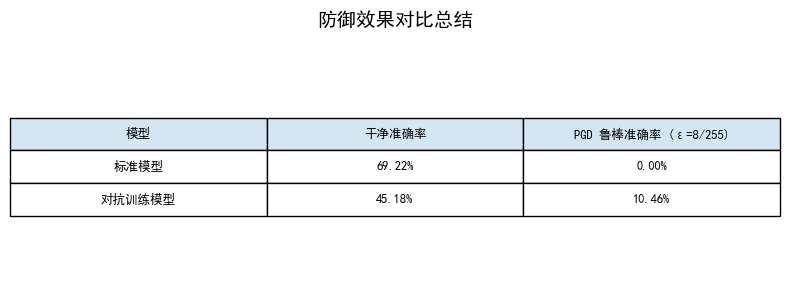

In [6]:
# 防御效果对比总结表（图表形式）
# epsilons = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15]
clean_std = acc_std_pgd[0]
clean_rob = acc_rob_pgd[0]
robust_std = acc_std_pgd[4]  # epsilon = 8/255
robust_rob = acc_rob_pgd[4]

table_data = [
    ["标准模型", f"{clean_std:.2%}", f"{robust_std:.2%}"],
    ["对抗训练模型", f"{clean_rob:.2%}", f"{robust_rob:.2%}"]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
ax.axis("tight")
table = ax.table(cellText=table_data,
                 colLabels=["模型", "干净准确率", "PGD 鲁棒准确率 (ε=8/255)"],
                 cellLoc="center", loc="center", colColours=["#d4e6f1"]*3)
table.scale(1, 2)
plt.title("防御效果对比总结", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## 小结与讨论

- **实验观察**：对抗训练模型在干净样本上的准确率可能略低于标准训练模型，但在 FGSM/PGD 攻击下准确率下降更缓慢。
- **鲁棒性-准确率权衡**：增强对抗鲁棒性通常需要牺牲部分干净准确率，这是当前防御研究的核心挑战之一。
- **下一步**：可尝试更强的训练攻击（如多步 PGD、TRADES）或更大的模型容量，以进一步改善权衡。

对抗训练是最直接的防御思路——用攻击样本训练防御模型，但代价是干净准确率下降和训练时间翻倍。后续 Notebook 28 展示另一种思路：检测而非防御；Notebook 29 展示可证明的认证防御。
